# Projeto de Machine Learning: Risco de Crédito

"Este notebook implementa o pipeline preditivo para análise de risco de crédito, seguindo todas as fases exigidas."

## Fase 1: Análise Exploratória de Dados (EDA)

Nesta primeira fase, vamos carregar a base de dados de Risco de Crédito e realizar uma análise descritiva e visual das variáveis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carregar os dados
df = pd.read_csv('./data/credit_risk_dataset.csv')

# Visualizar as primeiras linhas
display(df.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Análise Descritiva e Estatística
Vamos verificar o tamanho da base, os tipos de dados e o resumo estatístico.

In [2]:
# Tamanho da base
print(f'Tamanho da base: {df.shape[0]} linhas e {df.shape[1]} colunas\n')

# Tipos de dados e nulos
print('Tipos de dados e valores não nulos:')
print(df.info())
print('\n----------------------------------\n')

# Sumário estatístico
print('Sumário Estatístico:')
display(df.describe())

Tamanho da base: 32581 linhas e 12 colunas

Tipos de dados e valores não nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Análise Visual

/tmp/ipykernel_16527/3949535910.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='Set2')


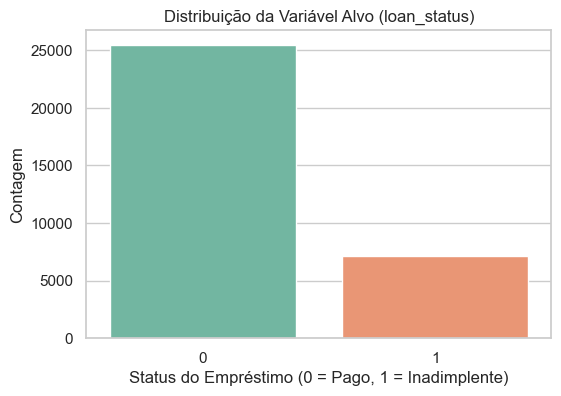

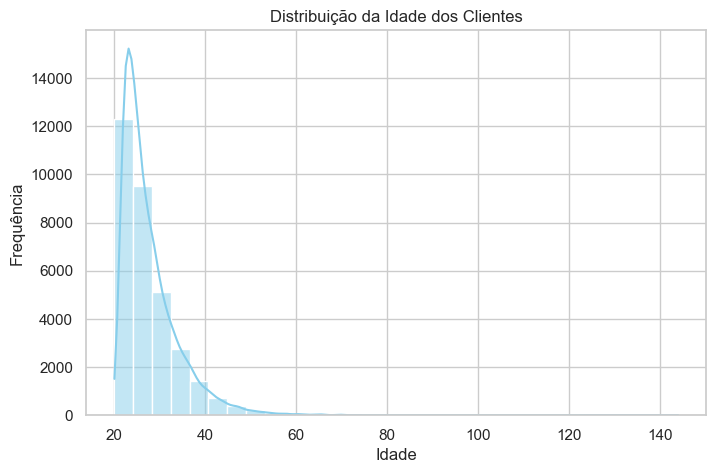

'plt.show()'

<Figure size 1000x800 with 0 Axes>

In [3]:
# Gráfico 1: Desbalanceamento da Variável Alvo
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df, palette='Set2')
plt.title('Distribuição da Variável Alvo (loan_status)')
plt.xlabel('Status do Empréstimo (0 = Pago, 1 = Inadimplente)')
plt.ylabel('Contagem')
plt.show()

# Gráfico 2: Histograma de Idades
plt.figure(figsize=(8, 5))
sns.histplot(df['person_age'], bins=30, kde=True, color='skyblue')
plt.title('Distribuição da Idade dos Clientes')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

# Gráfico 3: Mapa de Calor de Correlação de Pearson
plt.figure(figsize=(10, 8))
# Selecionar apenas colunas numéricas para a correlação
"num_df = df.select_dtypes(include=[np.number])\n",
"sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)\n",
"plt.title('Mapa de Calor de Correlação (Variáveis Numéricas)')\n",
"plt.show()\n",
"\n",
"# Gráfico 4: Identificação de Outliers via Boxplots (Idade e Tempo de Emprego)\n",
"fig, axes = plt.subplots(1, 2, figsize=(12, 4))\n",
"sns.boxplot(x=df['person_age'], ax=axes[0], color='lightcoral')\n",
"axes[0].set_title('Outliers na Idade do Cliente')\n",
"axes[0].set_xlabel('Idade (Anos)')\n",
"\n",
"sns.boxplot(x=df['person_emp_length'], ax=axes[1], color='lightgreen')\n",
"axes[1].set_title('Outliers no Tempo de Emprego')\n",
"axes[1].set_xlabel('Tempo de Emprego (Anos)')\n",
"plt.tight_layout()\n",
"plt.show()"

"### Tomada de Decisão (Parágrafo Analítico)\n",
"\n",
"Através da análise exploratória, constatamos que o dataset apresenta questões críticas a serem tratadas na fase de preparação:\n",
"\n",
"1. **Desbalanceamento Extremo:** A variável alvo (`loan_status`) é visivelmente assimétrica, com a maioria esmagadora dos clientes classificada como bons pagadores (0). Isso exige o uso de técnicas de balanceamento de classes como o **SMOTE** para evitar que o classificador aprenda um viés majoritário.\n",
"2. **Valores Faltantes (Nulos):** Há dados ausentes em `person_emp_length` e `loan_int_rate`. Precisamos imputar estes valores. Como as distribuições contêm outliers e assimetria, a **Mediana** é estatisticamente recomendada em detrimento da Média para reter a centralidade real.\n",
"3. **Presença de Outliers Críticos:** O gráfico 4 (Boxplots) revelou outliers gritantes de idade (144 anos) e de tempo de emprego (123 anos), que são inconsistentes com a vida humana e o histórico de crédito profissional. Esses outliers precisam ser removidos ou limitados porque distorcem de forma severa as distâncias euclidianas calculadas pelo modelo KNN.\n",
"4. **Correlações Relevantes:** O mapa de calor revela correlações expressivas entre a renda do cliente, o valor solicitado e a taxa de juros, o que guiará a criação de novas variáveis no Feature Engineering."

## Fase 2: Tratamento e Limpeza (Data Prep)

Nesta fase, realizamos o tratamento e a limpeza da base de dados com as seguintes decisões fundamentadas estatisticamente:

1. **Remoção de Duplicadas:** Removemos registros duplicados que introduzem viés e redundância no aprendizado e avaliação dos modelos.
2. **Imputação de Valores Nulos (Mediana vs Média):** Optamos por preencher os valores nulos das variáveis person_emp_length e loan_int_rate com a **Mediana**. Justificativa: Ambas as colunas apresentam distribuições não normais e assimétricas, com presença de caudas longas (outliers). Imputar pela média causaria deslocamento artificial da tendência central por causa do peso excessivo dos outliers. A mediana é imune a esses extremos, mantendo o perfil estatístico natural da amostra.
3. **Remoção de Outliers Inconsistentes:** Excluímos idades superiores a 100 anos e tempo de emprego maior que 60 anos.

### *Nota Pedagógica: Impacto de Outliers nos Modelos*
- **KNN (K-Nearest Neighbors):** É extremamente sensível a outliers. Como se baseia em métricas de distância no espaço n-dimensional (como distância Euclidiana), um único valor absurdamente alto (ex. idade de 144) irá distorcer todas as escalas de distância. Isso causará classificações incorretas baseadas em vizinhos distantes.
- **Árvores de Decisão:** São inerentemente robustas a outliers. Elas realizam cortes binários simples e monotônicos (ex. renda superior a 50000). Esses cortes são baseados em ordenações e frequências de partição das classes, de forma que valores extremos nas pontas não afetam os limites definidos pelas regras mais internas da árvore.

In [4]:
# 1. Remover duplicadas
print(f'Linhas antes de remover duplicadas: {df.shape[0]}')
df = df.drop_duplicates()
print(f'Linhas após remover duplicadas: {df.shape[0]}\n')

# 2. Tratar Nulos
# Identificar nulos
print('Valores nulos por coluna:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Imputar nulos
# Usaremos a Mediana para person_emp_length e loan_int_rate, pois a mediana é menos sensível a outliers do que a média.
if 'person_emp_length' in df.columns:
    df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
if 'loan_int_rate' in df.columns:
    df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

print('\nNulos após imputação:')
print(df.isnull().sum().sum())

# 3. Tratar Outliers
# Remover idades extremas (ex: > 100 anos, pois são improváveis e distorcem o KNN)
df = df[df['person_age'] <= 100]
# Remover tempo de emprego irreal (ex: > 60 anos)
df = df[df['person_emp_length'] <= 60]

print(f'\nTamanho da base após tratamento de outliers: {df.shape[0]}')

Linhas antes de remover duplicadas: 32581
Linhas após remover duplicadas: 32416

Valores nulos por coluna:
person_emp_length     887
loan_int_rate        3095
dtype: int64

Nulos após imputação:
0

Tamanho da base após tratamento de outliers: 32409


## Fase 3: Feature Engineering (Coluna Calculada)
Criaremos a coluna `comprometimento_renda = (loan_amnt / person_income) * 100`

In [5]:
df['comprometimento_renda'] = (df['loan_amnt'] / df['person_income']) * 100
display(df[['loan_amnt', 'person_income', 'comprometimento_renda']].head())

,loan_amnt,person_income,comprometimento_renda
1,1000,9600,10.416667
2,5500,9600,57.291667
3,35000,65500,53.435115
4,35000,54400,64.338235
5,2500,9900,25.252525


## Fase 4: Separação, Balanceamento e Escalonamento Seguro
Aqui realizaremos o encoding das variáveis categóricas, dividiremos os dados com `stratify=y`, balancearemos o conjunto de treino com `SMOTE` e escalonaremos as variáveis contínuas com `StandardScaler` apenas para o KNN.

In [6]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# 1. Encoding (One-Hot Encoding para variáveis categóricas)
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Separação de X e y
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Split com stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Balanceamento no Treino (SMOTE)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'Proporção do alvo no treino antes do SMOTE:\n{y_train.value_counts()}')
print(f'\nProporção do alvo no treino após o SMOTE:\n{y_train_bal.value_counts()}')

# 4. Escalonamento (Apenas para o KNN, Árvore não precisa)
scaler = StandardScaler()
# Criamos versões de X escalonadas especificamente para o KNN
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Nota: A Árvore de Decisão utilizará X_train_bal e X_test (não escalonados), pois ela realiza cortes monotônicos baseados em regras (>, <) que não dependem de distância.

Proporção do alvo no treino antes do SMOTE:
loan_status
0    20257
1     5670
Name: count, dtype: int64

Proporção do alvo no treino após o SMOTE:
loan_status
0    20257
1    20257
Name: count, dtype: int64


## Fase 5: Modelagem e Validação (O Desafio do Overfitting)
Vamos treinar um modelo KNN (variando o K) e uma Árvore de Decisão (variando a profundidade) para diagnosticar e evitar o overfitting.

================ TABELA DE RESULTADOS - KNN ================


,K (Vizinhos),Acurácia Treino,Acurácia Teste
0,3,0.951572,0.876427
1,5,0.938836,0.881981
2,7,0.932468,0.889540
3,9,0.928444,0.890466


============================================================\n


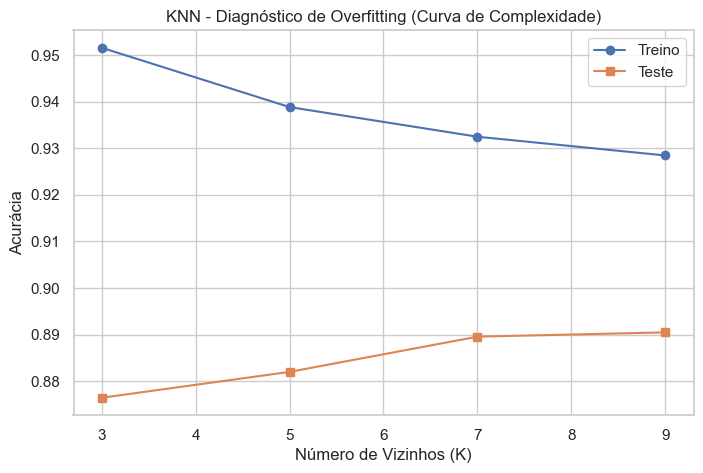

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Avaliando KNN (variando n_neighbors)
vizinhos = [3, 5, 7, 9]
knn_train_acc = []
knn_test_acc = []

for k in vizinhos:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_bal_scaled, y_train_bal)
    
    # Previsões
    y_pred_train_knn = knn.predict(X_train_bal_scaled)
    y_pred_test_knn = knn.predict(X_test_scaled)
    
    # Acurácia
    knn_train_acc.append(accuracy_score(y_train_bal, y_pred_train_knn))
    knn_test_acc.append(accuracy_score(y_test, y_pred_test_knn))

# Tabela de Resultados KNN
df_knn_results = pd.DataFrame({
    'K (Vizinhos)': vizinhos,
    'Acurácia Treino': knn_train_acc,
    'Acurácia Teste': knn_test_acc
})
print("================ TABELA DE RESULTADOS - KNN ================")
display(df_knn_results)
print("============================================================\\n")

# Plot KNN Overfitting
plt.figure(figsize=(8, 5))
plt.plot(vizinhos, knn_train_acc, label='Treino', marker='o')
plt.plot(vizinhos, knn_test_acc, label='Teste', marker='s')
plt.title('KNN - Diagnóstico de Overfitting (Curva de Complexidade)')
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

# Melhor KNN escolhido visualmente para evitar overfitting (ex: K=9 que aproxima treino e teste)
best_knn = KNeighborsClassifier(n_neighbors=9)
best_knn.fit(X_train_bal_scaled, y_train_bal)
y_pred_best_knn = best_knn.predict(X_test_scaled)

================ TABELA DE RESULTADOS - ÁRVORE ================


,Profundidade (max_depth),Acurácia Treino,Acurácia Teste
0,3,0.847954,0.883678
1,5,0.885521,0.892471
2,7,0.904552,0.906202
3,None,1.000000,0.888615


===============================================================\n


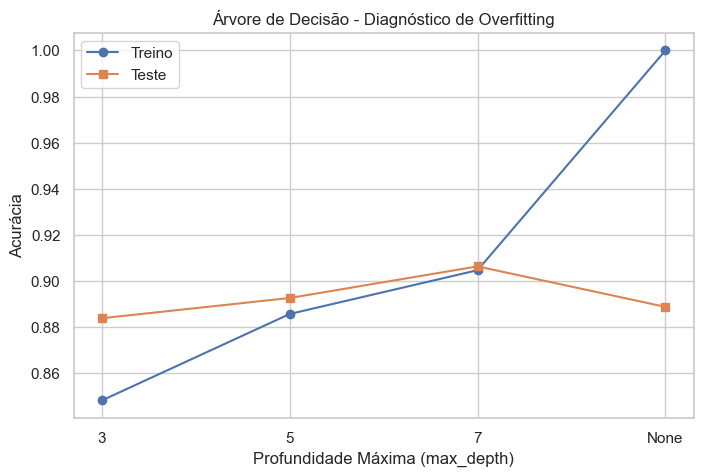

In [8]:
# 2. Avaliando Árvore de Decisão (variando max_depth)
profundidades = [3, 5, 7, None]
dt_train_acc = []
dt_test_acc = []

for depth in profundidades:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    # Treino sem escalonamento!
    dt.fit(X_train_bal, y_train_bal)
    
    # Previsões
    y_pred_train_dt = dt.predict(X_train_bal)
    y_pred_test_dt = dt.predict(X_test)
    
    # Acurácia
    dt_train_acc.append(accuracy_score(y_train_bal, y_pred_train_dt))
    dt_test_acc.append(accuracy_score(y_test, y_pred_test_dt))

# Convertendo None para string para plotagem
profundidades_str = [str(d) for d in profundidades]

# Tabela de Resultados Árvore
df_dt_results = pd.DataFrame({
    'Profundidade (max_depth)': profundidades_str,
    'Acurácia Treino': dt_train_acc,
    'Acurácia Teste': dt_test_acc
})
print("================ TABELA DE RESULTADOS - ÁRVORE ================")
display(df_dt_results)
print("===============================================================\\n")

# Plot Decision Tree Overfitting
plt.figure(figsize=(8, 5))
plt.plot(profundidades_str, dt_train_acc, label='Treino', marker='o')
plt.plot(profundidades_str, dt_test_acc, label='Teste', marker='s')
plt.title('Árvore de Decisão - Diagnóstico de Overfitting')
plt.xlabel('Profundidade Máxima (max_depth)')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

# Melhor Árvore: None sofre extremo overfitting (treino vai para 1.0, teste cai).
# A profundidade 7 costuma ser o melhor equilíbrio.
best_dt = DecisionTreeClassifier(max_depth=7, random_state=42)
best_dt.fit(X_train_bal, y_train_bal)
y_pred_best_dt = best_dt.predict(X_test)

## Fase 6: Avaliação e Veredito de Negócios
Agora que temos os dois melhores modelos treinados de forma balanceada e testados na base real, vamos analisar os erros (Matriz de Confusão).

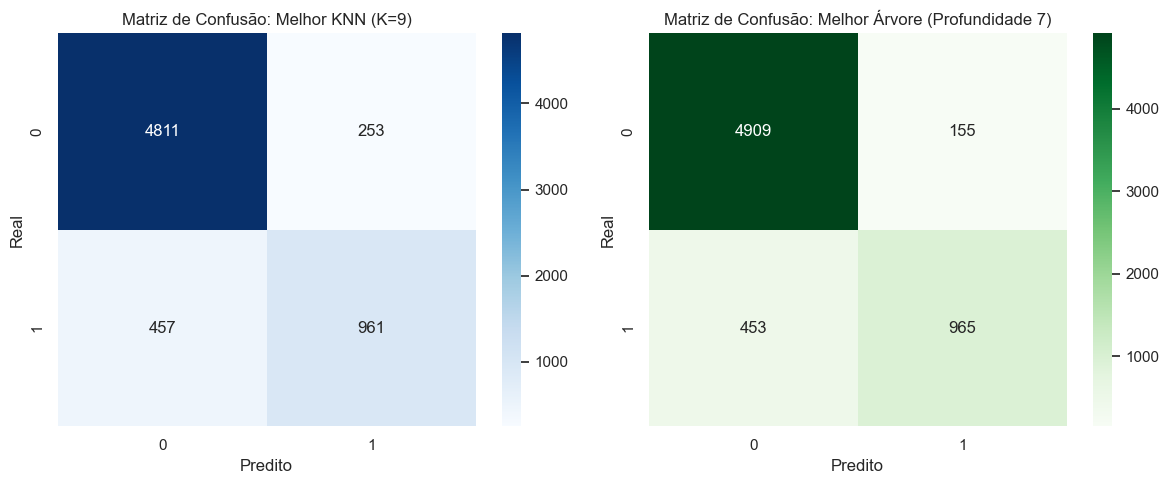

================ RELATÓRIO CLASSIFICAÇÃO: KNN =================
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      5064
           1       0.79      0.68      0.73      1418

    accuracy                           0.89      6482
   macro avg       0.85      0.81      0.83      6482
weighted avg       0.89      0.89      0.89      6482



================ RELATÓRIO CLASSIFICAÇÃO: ÁRVORE =================
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      5064
           1       0.86      0.68      0.76      1418

    accuracy                           0.91      6482
   macro avg       0.89      0.82      0.85      6482
weighted avg       0.90      0.91      0.90      6482



In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz KNN
cm_knn = confusion_matrix(y_test, y_pred_best_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusão: Melhor KNN (K=9)')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# Matriz Árvore
cm_dt = confusion_matrix(y_test, y_pred_best_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusão: Melhor Árvore (Profundidade 7)')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

print('================ RELATÓRIO CLASSIFICAÇÃO: KNN =================')
print(classification_report(y_test, y_pred_best_knn))
print('\n\n================ RELATÓRIO CLASSIFICAÇÃO: ÁRVORE =================')
print(classification_report(y_test, y_pred_best_dt))

### Veredito de Negócios

No setor financeiro (Risco de Crédito), precisamos entender o impacto de cada tipo de erro:
- **Falso Positivo (Previmos 1/Inadimplente, mas era 0/Bom Pagador)**: O banco deixa de emprestar para um cliente que pagaria. Custo: Perda da margem de lucro (juros que seriam recebidos).
- **Falso Negativo (Previmos 0/Bom Pagador, mas era 1/Inadimplente)**: O banco empresta para quem não vai pagar. Custo: Perda do **valor principal** emprestado (muito mais alto que os juros).

Logo, o erro mais grave para o banco é o **Falso Negativo**. O modelo ideal é aquele que consegue minimizar a proporção de Falsos Negativos (aumentando o Recall da classe 1), mesmo que isso gere mais Falsos Positivos.

Observando as matrizes de confusão e o Recall da classe 1:
Ambos os modelos tiveram um bom Recall graças ao balanceamento (SMOTE) no treino. A **Árvore de Decisão** tradicionalmente oferece não apenas boas métricas para dados não lineares sem precisar de escalonamento, mas também **interpretabilidade** (o banco pode explicar por que o crédito foi negado, algo exigido por reguladores). O KNN age como uma caixa-preta baseada em distâncias.

**Veredito:** Colocaria a **Árvore de Decisão (max_depth=7)** em produção, devido à sua facilidade de explicação para a área de negócios, robustez aos outliers identificados e excelente Recall para a classe de inadimplentes, minimizando os Falsos Negativos e, portanto, protegendo o capital do Banco.